# Split, population and data-contract audit

This notebook verifies that the analysed pixels are exactly those the real-only baselines were trained and tested on, defines the four evaluation populations and documents what the held-out images and the two spectral axes contain. Every later notebook relies on these facts.

## Introduction

The saved models of the synthetic-pretraining campaign store only their model configuration. Their data
contract (cohort, 20 % proportional subset, 90/5/5 split, train-only molecule columns) is therefore
re-resolved from the campaign YAML by the runtime's own plan resolver and compared with the persisted
artifacts. On top of that contract four pixel populations are evaluated:

* `train` and `test`: the saved partitions of the subset;
* `test_extended`: additional cohort pixels *outside* the subset, drawn only for classes with fewer than
  20 test positives;
* `heldout_image`: every non-empty pixel of the three datasets excluded from the cohort.

### Assumptions

* The recovered split `tmp/pretrain_repair/bundle/source_split.yaml` is the split of the original training
  run; agreement with it validates the re-resolution. If it were unavailable, only model-configuration
  checks would remain.
* `test_extended` pixels come from the same images as the training pixels. They share the statistical
  status of `test` (seen images, unseen pixels) and are reported separately so that `test` stays the
  original partition.
* Held-out pixels are paired across both axes (identical source spectra); pixels empty on either axis would
  be dropped (none were).

### Notation

* $d$: source dataset (image); $m$: m/z; $W$: 100 Da window $[a, a + 100)$.
* $n_c^{P}$: number of annotated positives of class $c$ in population $P$.
* Axis names: `axis-200-900` (1273 bins) and `axis-100-3000` (5273 bins), bin width 0.55 Da.

## Configuration

In [1]:
import logging
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

# Library modules log INFO to stdout; warnings stay visible, progress messages do not.
logging.disable(logging.INFO)
current_path = Path.cwd().resolve()
repository_root = next(path for path in (current_path, *current_path.parents) if (path / "pyproject.toml").is_file())
os.chdir(repository_root)

from msi_autoencoder_wrapper.analysis.autoencoder.experiments import pretraining_campaign as campaign
from msi_autoencoder_wrapper.analysis.autoencoder.experiments.pretraining_campaign_precompute import (
    load_metadata, load_table, run_command,
)
from msi_autoencoder_wrapper.analysis.precompute.notebook_inputs import load_model_catalog, load_visualization_theme
from msi_autoencoder_wrapper.visualization import pretraining as figures

SETTINGS_PATH = Path("assets/experiments/autoencoder_architecture/notebooks/segmentation_model/20_09_metaspace_pretrain/analysis_settings.yaml")
ANALYSIS = "split_population_audit"
AXIS = None

settings = campaign.load_settings(SETTINGS_PATH)
theme = load_visualization_theme(settings).with_overrides(figure_dpi=100)
catalog = load_model_catalog(settings)
metadata = load_metadata(settings, ANALYSIS, AXIS)
pd.set_option("display.precision", 4)
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_rows", 80)


def table(name: str) -> pd.DataFrame:
    """Load one canonical table written for this notebook by the precompute."""
    return load_table(settings, ANALYSIS, name, AXIS)


def mean_sd(frame: pd.DataFrame, keys: list, columns: list) -> pd.DataFrame:
    """Mean and SD over repetitions of the given columns (presentation helper)."""
    long = frame.melt(id_vars=keys, value_vars=columns, var_name="quantity", value_name="value")
    return long.groupby([*keys, "quantity"]).value.agg(["mean", "std"]).unstack("quantity")


LABELS = list(catalog.drop_duplicates("display_label").sort_values("display_order").display_label)
LABEL_COLORS = {label: figures.model_color(label, theme, position) for position, label in enumerate(LABELS)}
POPULATION_COLORS = {name: figures.population_color(name, theme) for name in figures.POPULATION_ORDER}
CLASS_SET_COLORS = {name: figures.class_set_color(name, theme) for name in figures.CLASS_SET_ORDER}
print("Analysis:", ANALYSIS, "| axis:", AXIS, "| models:", len(metadata["models"]))
print("Cache keys:", metadata["cache_keys"])

Analysis: split_population_audit | axis: None | models: 10
Cache keys: {'plan': 'f34a92a8f6f7833f', 'populations': '513690bdd78a83ce', 'inference': '0243c1efb93b9c4c'}


## Producing the tables this notebook reads

### Methodology

#### Implementation

The shared cache stages `campaign_plan` (plan resolution and verification) and `populations` (decoding of
every population on both axes, evidence states, pixel identities, coordinates, class catalogue, METASPACE
alignment) produce everything summarised here; `split_population_audit` only re-shapes those records.

The command below is generated by the precompute entry point itself; if a table is missing, `load_table` raises with the same command.

In [2]:
print(run_command(settings, ANALYSIS))

nohup uv run --extra cu118 python -m msi_autoencoder_wrapper.analysis.precompute --settings /home/max/repositories/MSIAutoEncoderWrapper/assets/experiments/autoencoder_architecture/notebooks/segmentation_model/20_09_metaspace_pretrain/analysis_settings.yaml --analysis split_population_audit > /home/max/repositories/MSIAutoEncoderWrapper/assets/experiments/autoencoder_architecture/notebooks/segmentation_model/20_09_metaspace_pretrain/shared_precompute.log 2>&1 &


### Remarks

### Notes

## Verification of the re-resolved data contract

### Methodology

#### Theoretical

The resolved contract is valid when (i) the resolved model configuration of every analysed model equals its
saved `config.json`, (ii) the number of train-only molecule columns equals the head's output dimension,
(iii) all models share one split manifest (paired design) and (iv) that manifest equals the recovered split
of the original run (seed, dataset fingerprint and every assignment).

#### Implementation

`verify_campaign_plan` compares canonical JSON fingerprints of the configurations and the complete
assignment lists. Any failed check aborts the precompute, so a table without failures is a precondition of
every later result.

#### Figure descriptions

No figure; the table lists every check with its subject and outcome.

In [3]:
verification = table('verification')
print(verification.passed.value_counts())
display(verification.groupby('check').agg(checks=('passed', 'size'), passed=('passed', 'sum')))

passed
True    24
Name: count, dtype: int64


,checks,passed
check,,
head_columns,10,10
model_configuration,10,10
reference_split_assignments,1,1
reference_split_dataset_fingerprint,1,1
reference_split_seed,1,1
single_paired_split,1,1


### Remarks

- All 24 checks pass: configurations and head widths of all ten models, one shared split, and identity with the recovered split (seed, fingerprint, every assignment).

### Notes

## Population sizes per image

### Methodology

#### Theoretical

The populations differ in their relation to training: `train` pixels were optimised on, `test` pixels come
from the same images but were withheld, `test_extended` pixels come from the same images outside the 20 %
subset, and `heldout_image` pixels come from images never seen. The number of pixels per image determines
how much each image weighs in population-level means.

#### Implementation

Counts are grouped from the pixel identity table (`populations.csv` of the cache). Annotation visibility is
the training dataset's annotation policy (at least one mapped annotation on that axis); every population is
decoded regardless of visibility, and the flag is reported per axis.

#### Figure descriptions

Heat map: rows = source datasets, columns = populations, colour = number of pixels (logarithmic colour
would hide the small test counts, so values are annotated). The table below gives the annotation-visible
counts per axis.

population
train            70417.0
test              3910.0
test_extended     1227.0
heldout_image    29433.0
dtype: float64


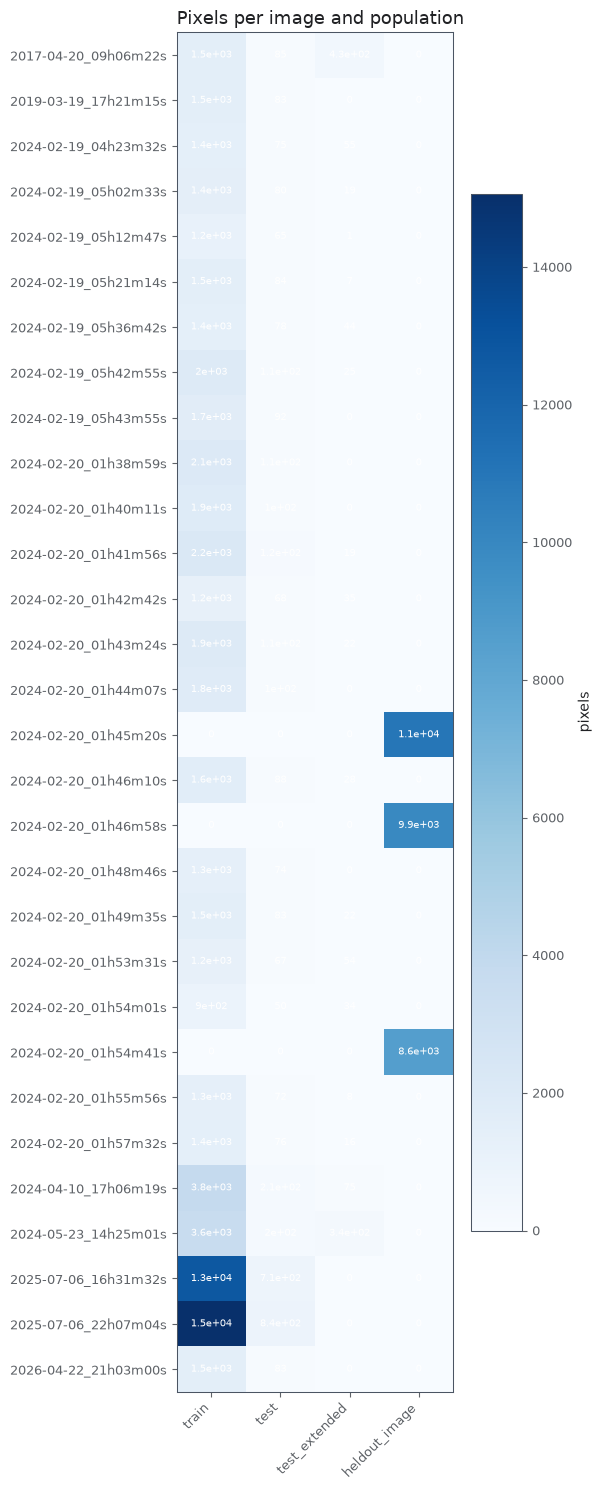

In [4]:
sizes = table('population_sizes')
counts = sizes.pivot_table(index='dataset_id', columns='population', values='pixels', aggfunc='sum').reindex(columns=['train', 'test', 'test_extended', 'heldout_image'])
print(counts.sum())
figures.matrix_heatmap(counts.fillna(0), title='Pixels per image and population', colorbar_label='pixels', annotate=True, cmap='Blues', theme=theme);

In [5]:
display(table('population_visibility').drop(columns=['model_id', 'model_alias', 'display_label', 'repetition'], errors='ignore'))

,axis,population,pixels,annotation_visible
0,axis-200-900,train,70417,70417
1,axis-200-900,test,3910,3910
2,axis-200-900,test_extended,1227,1226
3,axis-200-900,heldout_image,29433,29432
4,axis-100-3000,train,70417,70417
5,axis-100-3000,test,3910,3910
6,axis-100-3000,test_extended,1227,1227
7,axis-100-3000,heldout_image,29433,29433


### Remarks

- 70 417 / 3 910 / 1 227 / 29 433 pixels. One test-extension pixel and one held-out pixel are not annotation-visible on the 200-900 axis (their only annotations lie outside 200-900); they are evaluated like the others.

### Notes

## Training-time versus recomputed test Masserstein

### Methodology

#### Theoretical

        The final test evaluation stored in each model's history is compared with the mean Masserstein cost over
        every test pixel recomputed here with the same objective. Equality would confirm that the analysis sees the
        same pixels and the same model as training.

The trainer builds its validation and test data loaders from the phase configuration,
including `supervision_sampling` (positive : unlabelled = 1 : 1, drawn with replacement).
Every *recorded* validation and test value is therefore an estimate on a re-sampled,
class-balanced population, not the mean over the plain partition. Checkpoint selection
(`restore_best`) uses the same sampled validation loss.

#### Implementation

`recorded_test_masserstein` is the `masserstein` entry of the history record with `split == "test"`;
`recomputed_test_masserstein` is the plain mean of the per-pixel training Masserstein over the 3910 test
pixels; the relative difference is (recomputed - recorded) / recorded.

#### Figure descriptions

One point per repetition; x = model group, y = relative difference. The dashed line marks equality.

,display_label,repetition,recorded_test_masserstein,recomputed_test_masserstein,relative_difference
0,"Real-only baseline, 200-900 m/z",0,3.4861,3.2834,-0.0581
1,"Real-only baseline, 200-900 m/z",1,3.2330,2.9758,-0.0796
2,"Real-only baseline, 200-900 m/z",2,3.3539,3.1069,-0.0737
3,"Real-only baseline, 200-900 m/z",3,3.3627,3.1123,-0.0745
4,"Real-only baseline, 200-900 m/z",4,3.3354,3.1081,-0.0681
5,"Real-only baseline, 100-3000 m/z",0,4.1820,4.0381,-0.0344
6,"Real-only baseline, 100-3000 m/z",1,4.1735,4.0117,-0.0388
7,"Real-only baseline, 100-3000 m/z",2,3.8925,3.7285,-0.0421
8,"Real-only baseline, 100-3000 m/z",3,4.1521,4.0129,-0.0335
9,"Real-only baseline, 100-3000 m/z",4,4.3404,4.1471,-0.0445


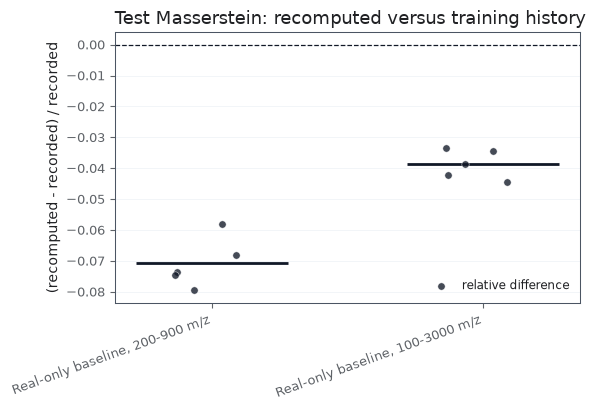

In [6]:
history = table('history_consistency')
display(history[['display_label', 'repetition', 'recorded_test_masserstein', 'recomputed_test_masserstein', 'relative_difference']])
figures.repetition_points(history.assign(kind='relative difference'), value='relative_difference', group='display_label', hue='kind', order=LABELS, hue_order=['relative difference'], colors={'relative difference': theme.baseline_color}, ylabel='(recomputed - recorded) / recorded', title='Test Masserstein: recomputed versus training history', reference=0.0, theme=theme);

### Remarks

- The recomputed test Masserstein is 5.8-8.0 % (200-900) and 3.4-4.5 % (100-3000) *lower* than the recorded value, consistently in all ten models. This is explained by the sampled test loader (P:U re-sampling), not by a different model or split; recorded validation/test values in `part_0_03`/`part_0_04` share this bias.

### Notes

## Test extension for under-represented classes

### Methodology

#### Theoretical

Per-class metrics are unreliable when a class has only a handful of test positives. For every head class
with $n_c^{\mathrm{test}} < 20$, pixels positive for $c$ are drawn from cohort pixels outside the subset
until $n_c = 20$ or the pool is exhausted. A pixel drawn for one class also counts for every other class it
carries.

#### Implementation

Classes are processed in sorted order with one generator (seed 42). The union of both axes' head classes is
used, so the extension pixels are identical on both axes. `shortfall > 0` marks classes whose pool was
exhausted.

#### Figure descriptions

Scatter: x = test positives before the extension, y = positives after it (both log scale); colour separates
classes that were topped up, unchanged or left short. Points on the diagonal were not changed.

status
unchanged    464
topped up     93
short          6
Name: count, dtype: int64


,class_name,test_positives,from_earlier_draws,added,final_positives,pool_candidates,shortfall,status
66,C15H14N4O|-H,1,0,15,16,15,4,short
81,C16H11ClN2O3|-H,1,0,12,13,12,7,short
95,C17H14O3|-H,1,0,14,15,14,5,short
142,C18H35IO2|[M]-,1,0,4,5,4,15,short
511,C53H100NO8P|-H,0,0,11,11,11,9,short
516,C57H86O4|[M]-,1,0,13,14,13,6,short


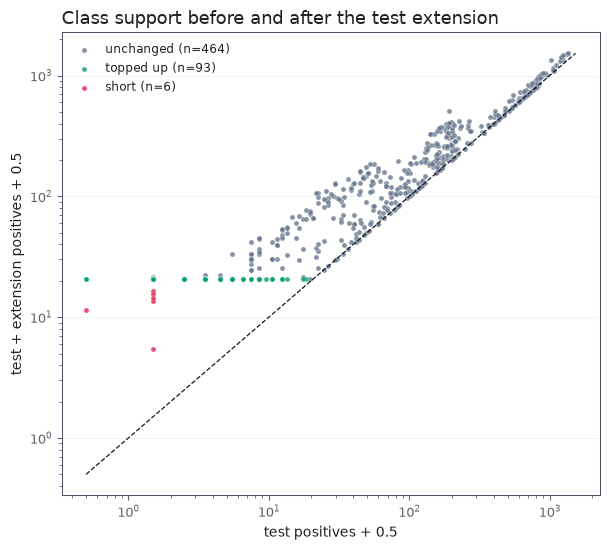

In [7]:
extension = table('test_extension')
extension['status'] = np.where(extension.shortfall > 0, 'short', np.where(extension.added > 0, 'topped up', 'unchanged'))
print(extension.status.value_counts())
display(extension[extension.shortfall > 0])
plot_frame = extension.assign(before=extension.test_positives + 0.5, after=extension.final_positives + 0.5)
figures.paired_scatter(plot_frame, x='before', y='after', hue='status', hue_order=['unchanged', 'topped up', 'short'], xlabel='test positives + 0.5', ylabel='test + extension positives + 0.5', title='Class support before and after the test extension', log=True, colors={'unchanged': theme.input_color, 'topped up': theme.model_palette[2], 'short': theme.residual_color}, theme=theme);

### Remarks

- 93 classes were topped up to 20 positives; 6 classes stay short (4-15 positives after the extension) because their pool is exhausted; per-class metrics of those remain noisy.

### Notes

## Class sets and class support per axis

### Methodology

#### Theoretical

A class is `common` when it is a head column on both axes, `extension` when it exists only on the wide axis
and its annotated m/z lies outside 200-900, and `boundary` when it exists only on the wide axis although its
m/z lies inside 200-900 (for example through bin mapping at an axis edge).

#### Implementation

Class m/z is the median annotated m/z over all datasets of the merged store. Positives per population are
available annotations (target and availability mask) in the decoded populations.

#### Figure descriptions

No figure; tables count classes per set and summarise positives per population.

In [8]:
coverage = table('class_coverage')
display(coverage.drop_duplicates(['axis', 'class_name']).groupby(['axis', 'class_set']).size().unstack(fill_value=0))
display(coverage.groupby(['axis', 'population']).positives.describe()[['mean', '50%', 'min', 'max']])
display(coverage[coverage.class_set != 'common'].drop_duplicates('class_name')[['class_name', 'mz', 'class_set']].sort_values('mz').head(60))

class_set,common,extension
axis,,
axis-100-3000,508,55
axis-200-900,508,0


mean     50%  min      max
axis          population                                    
axis-100-3000 heldout_image   232.3552     0.0  0.0  26685.0
              test            202.9290    83.0  0.0   1356.0
              test_extended    92.1226    53.0  0.0    445.0
              train          3644.1226  1482.0  1.0  24409.0
axis-200-900  heldout_image   230.4173     0.0  0.0  26685.0
              test            205.2736    81.0  1.0   1356.0
              test_extended    95.1024    53.0  0.0    445.0
              train          3684.6201  1449.0  1.0  24409.0

,class_name,mz,class_set
2552,C5H8O3|-H,115.0401,extension
2559,C6H12O2|-H,115.0765,extension
2523,C4H6O4|-H,117.0193,extension
2570,C7H6O2|-H,121.0295,extension
2323,C2H7NO3S|-H,124.0074,extension
2558,C6H10O3|-H,129.0557,extension
2568,C7H14O2|-H,129.0921,extension
2525,C4H7NO4|-H,132.0302,extension
2524,C4H6O5|-H,133.0142,extension
2581,C8H8O2|-H,135.0452,extension


### Remarks

- 508 common classes; the wide head adds 55 extension classes: 35 below 200 m/z and 20 at 906 m/z and above. No boundary class occurs.
- Median test positives per class is about 80; the held-out median is 0 (most head classes are not annotated in the three held-out images).

### Notes

## Annotations of the held-out images

### Methodology

#### Theoretical

The held-out images carry their own METASPACE annotations. An annotation can only be evaluated on an axis
when its m/z lies on that axis (`in_axis`) and it is a head column (`head_column >= 0`); otherwise it is
reported as `not_in_head` (a class never observed in training).

#### Implementation

The METASPACE ion images (`pixel_intensities.csv`) are aligned to the analysed pixels; the number of pixels
with a positive METASPACE intensity is counted per annotation.

#### Figure descriptions

No figure; the tables give per image and axis the number of annotations by status.

In [9]:
labels = table('heldout_label_coverage')
display(labels.groupby(['axis', 'dataset_id', 'in_axis', 'class_set']).size().unstack(fill_value=0))
display(labels[labels.axis == 'axis-100-3000'][['dataset_id', 'class_name', 'mz', 'class_set', 'metaspace_positive_pixels']].sort_values(['dataset_id', 'mz']))

class_set                                   common  extension  not_in_head
axis          dataset_id           in_axis                                
axis-100-3000 2024-02-20_01h45m20s True          7          2            0
              2024-02-20_01h46m58s True          9          2            0
              2024-02-20_01h54m41s True         13          0            1
axis-200-900  2024-02-20_01h45m20s False         0          0            2
                                   True          7          0            0
              2024-02-20_01h46m58s False         0          0            2
                                   True          9          0            0
              2024-02-20_01h54m41s False         0          0            1
                                   True         13          0            0

,dataset_id,class_name,mz,class_set,metaspace_positive_pixels
34,2024-02-20_01h45m20s,C7H6O4|-H,153.0193,extension,1700
38,2024-02-20_01h45m20s,C6H8N2O3|-H,155.0462,extension,2163
36,2024-02-20_01h45m20s,C19H22O4|-H,313.1445,common,9862
35,2024-02-20_01h45m20s,C14H30O8|-H,325.1868,common,218
42,2024-02-20_01h45m20s,C19H34O12|-H,453.1978,common,1856
41,2024-02-20_01h45m20s,C41H73NO9|-H,722.5213,common,7605
37,2024-02-20_01h45m20s,C41H73O8P|-H,723.4970,common,1116
39,2024-02-20_01h45m20s,C44H75O8P|[M]-,762.5205,common,7672
40,2024-02-20_01h45m20s,C47H79O12P|-H,865.5236,common,6301
46,2024-02-20_01h46m58s,C7H6O4|-H,153.0193,extension,3125


### Remarks

- After removing duplicated METASPACE rows the held-out images carry 9, 11 and 14 annotations. On the 200-900 axis 2 (01h45m20s: 153.0 and 155.0 m/z), 2 (01h46m58s: 153.0 and 943.5 m/z) and 1 (01h54m41s: 904.6 m/z) unique annotations lie outside the axis; on the wide axis they become extension classes, except one annotation of 01h54m41s (904.6 m/z) that is not a head class.

### Notes

## Acquired m/z range per image

### Methodology

#### Theoretical

Whether a reconstruction that is empty in some m/z window is an error depends on whether the instrument
recorded signal there. The mean fraction of the total ion current in every 100 Da window measures the
acquired range per image.

#### Implementation

`mean_input_mass` is the mean over the image's pixels of the TIC fraction of the input spectrum inside the
window (wide axis, training and held-out pixels). A window counts as having signal when this mean is at
least 1e-3.

#### Figure descriptions

Heat map: rows = images (train pixels of cohort images, then held-out images), columns = m/z windows of the
wide axis up to 1500, colour = mean TIC fraction. White means no recorded signal.

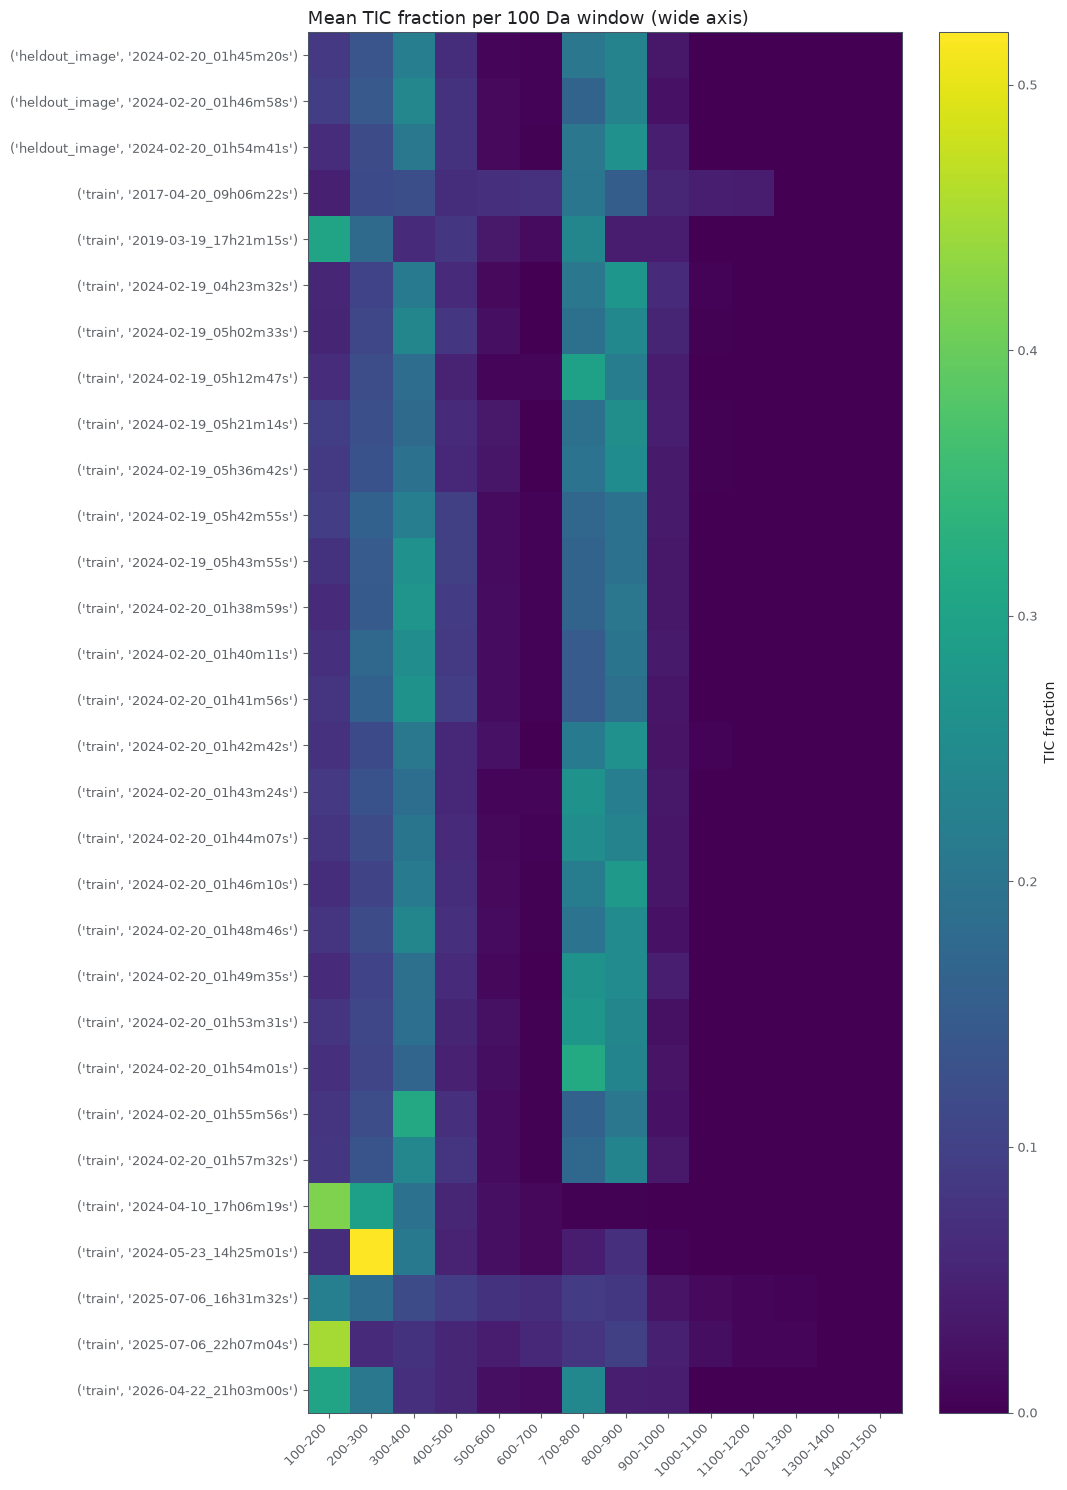

In [10]:
acquisition = table('acquisition_windows')
wide = acquisition[(acquisition.axis == 'axis-100-3000') & (acquisition.window_lower < 1500)]
matrix = wide.pivot_table(index=['population', 'dataset_id'], columns='window_label', values='mean_input_mass')
matrix = matrix[sorted(matrix.columns, key=lambda label: float(label.split('-')[0]))]
figures.matrix_heatmap(matrix, title='Mean TIC fraction per 100 Da window (wide axis)', colorbar_label='TIC fraction', cmap='viridis', theme=theme);

In [11]:
ranges = table('acquisition_range')
display(ranges.groupby(['axis', 'population']).agg(lowest=('lowest_window_lower', 'min'), highest=('highest_window_upper', 'max'), highest_median=('highest_window_upper', 'median')))

lowest  highest  highest_median
axis          population                                    
axis-100-3000 heldout_image   100.0   1000.0          1000.0
              train           100.0   1300.0          1000.0
axis-200-900  heldout_image   200.0    900.0           900.0
              train           200.0    900.0           900.0

### Remarks

- Recorded signal ends at 1000 m/z in the held-out images and at 1000-1300 m/z in the training images; windows 1300-3000 carry no signal in any image. An empty reconstruction there is correct, not a failure.
- The 100-200 window holds a large TIC share in the training images but a much smaller one in the held-out images (see `part_1_02`).

### Notes

## Alignment of METASPACE ion images

### Methodology

#### Theoretical

METASPACE exports pixel coordinates in its own convention. The coordinate offset is correct when the METASPACE
ion image of every annotation correlates best with the ion image computed from the analysed input spectra.

#### Implementation

For each candidate offset the Spearman correlation between METASPACE and input ion images (reference axis,
bin of the annotated m/z +/- 1 bin) is computed per annotation; the median over annotations is reported. The
precompute aborts when the configured offset is not the best candidate.

#### Figure descriptions

No figure; the table lists coverage and median correlation per image and offset.

In [12]:
display(table('metaspace_alignment').sort_values(['dataset_id', 'median_spearman'], ascending=[True, False]))

,dataset_id,offset_x,offset_y,coverage,median_spearman,ions,configured
0,2024-02-20_01h45m20s,-1,-1,1.0000,0.5006,7,True
2,2024-02-20_01h45m20s,-1,0,0.9915,0.4310,7,False
3,2024-02-20_01h45m20s,0,-1,0.9866,0.4255,7,False
1,2024-02-20_01h45m20s,0,0,0.9831,0.4116,7,False
4,2024-02-20_01h45m20s,1,1,0.9663,0.3727,7,False
5,2024-02-20_01h46m58s,-1,-1,1.0000,0.6630,9,True
7,2024-02-20_01h46m58s,-1,0,0.9913,0.5362,9,False
8,2024-02-20_01h46m58s,0,-1,0.9844,0.5338,9,False
6,2024-02-20_01h46m58s,0,0,0.9805,0.5047,9,False
9,2024-02-20_01h46m58s,1,1,0.9610,0.4462,9,False


### Remarks

- Offset (-1, -1) is best for all three images with full coverage; median input-METASPACE Spearman 0.45-0.66 at that offset.

### Notes

## Results / Summary

### LLM

- **Contract:** the analysed pixels, splits and head columns are exactly those of the trained models (all checks pass against the recovered split). Results of later notebooks are therefore not confounded by a data mismatch.
- **Populations:** train 70 417, test 3 910, rare-class test extension 1 227 (93 classes topped up, 6 still short), held-out images 29 433 pixels (three whole images, no empty pixel removed).
- **Methodological caveat (training code):** recorded validation and test losses are computed on a supervision-sampled population; the plain test Masserstein is 3-8 % lower. Checkpoint selection used the sampled validation loss.
- **Acquisition:** no image carries signal above 1300 m/z (held-out: above 1000 m/z). Most of the wide axis is empty by acquisition; the meaningful extension is 100-200 and 900-1300 m/z.
- **Held-out labels:** 9-14 annotations per image; few annotations lie outside 200-900. Held-out prediction metrics rest on few classes and should be read per image.

### Person